In [2]:
# 定义标签和作文名称对应关系
classification_names = {
    0: '上衣',
    1: '鞋',
    2: '包',
    3: '下装',
    4: '手表'
}


In [36]:
import torch
from PIL import Image
import torchvision.transforms as T
import os
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from common.utils import *
from image_denoising.denoising_config import *
import pandas as pd
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 自定义数据集类

In [16]:
class ImageLabelDataset(Dataset):
    # 初始化
    def __init__(self, image_dir, label_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        label_data = pd.read_csv(label_path)
        self.labels = label_data['target'].tolist()
        self.image_names = sorted_alphanum(os.listdir(image_dir))

    # 获取数据集长度
    def __len__(self):
        return len(self.image_names)

    # 获取数据集的某一个数据
    def __getitem__(self, index):
        # 1. 图片的完整访问路径
        image_path = os.path.join(self.image_dir, self.image_names[index])
        # 2. 打开图片
        image = Image.open(image_path).convert("RGB")
        # 3. 应用转换操作,得到tensor
        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            raise ValueError("transform 参数不能为None!")
        # 4. 找到图片对应的标签
        label = self.labels[index]
        return image_tensor, label


In [18]:
transforms = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
])
# 创建数据集
dataset = ImageLabelDataset(image_dir=IMG_PATH, label_path='../common/fashion-labels.csv', transform=transforms)
print(f"数据集大小: {len(dataset)}")


数据集大小: 24853


## 划分数据集

In [19]:
train_dataset, test_dataset = random_split(dataset, [0.75, 0.25])
print(f"训练集大小: {len(train_dataset)}, 测试集大小: {len(test_dataset)}")

训练集大小: 18640, 测试集大小: 6213


In [43]:
batch_size = 32
# 创建加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)


In [26]:
for input, target in train_loader:
    print(input.shape)
    print(target.shape)
    break

torch.Size([32, 3, 64, 64])
torch.Size([32])


## 定义模型

In [34]:
class ClassificationModel(nn.Module):
    def __init__(self, n_classes=5):
        super(ClassificationModel, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(1),
            nn.Linear(16 * 16 * 16, n_classes),
        )

    # 前向传播
    def forward(self, x):
        return self.model(x)



In [35]:
model = ClassificationModel()
model.to(device)
input = torch.randn(1, 3, 64, 64)
input = input.to(device)
output = model(input)
print(output.shape)

torch.Size([1, 5])


## 模型训练

In [38]:
# 超参数
lr = 0.001
epochs = 10

# 损失函数
loss_fn = nn.CrossEntropyLoss()
# 优化器
optimizer = optim.Adam(model.parameters(), lr=lr)

In [39]:
# 训练流程
for epoch in range(epochs):
    model.train()
    train_loss = 0
    total = 0
    for input, target in train_loader:
        input = input.to(device)
        target = target.to(device)
        # 前向传播
        output = model(input)
        # 计算损失
        loss = loss_fn(output, target)
        # 反向传播 + 梯度清零 + 参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 累加损失
        train_loss += loss.item()
        total += 1
    print(f"第 {epoch + 1} 轮训练结束, 平均损失: {train_loss / total:.4f}")

第 1 轮训练结束, 平均损失: 0.2053
第 2 轮训练结束, 平均损失: 0.0739
第 3 轮训练结束, 平均损失: 0.0578
第 4 轮训练结束, 平均损失: 0.0501
第 5 轮训练结束, 平均损失: 0.0414
第 6 轮训练结束, 平均损失: 0.0357
第 7 轮训练结束, 平均损失: 0.0305
第 8 轮训练结束, 平均损失: 0.0254
第 9 轮训练结束, 平均损失: 0.0237
第 10 轮训练结束, 平均损失: 0.0201


## 测试

In [48]:
# 模型输入新图片,进行预测
data_iter = __builtins__.iter(test_loader)

In [80]:
images, targets = next(data_iter)
print(images.shape)
print(targets.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [81]:
# 前向传播
with torch.no_grad():
    output = model(images.to(device))

print(output.shape)

torch.Size([32, 5])


In [82]:
# 得到分类标签
pred_labels = output.argmax(dim=1).cpu().numpy()
print(pred_labels.shape)


(32,)


In [83]:
# 转换输入图片,为画图做准备
images = images.permute(0, 2, 3, 1).numpy()
print(images.shape)

(32, 64, 64, 3)


1-label: 0
1-pred: 上衣

2-label: 0
2-pred: 上衣

3-label: 1
3-pred: 鞋

4-label: 0
4-pred: 上衣

5-label: 0
5-pred: 上衣

6-label: 0
6-pred: 上衣

7-label: 0
7-pred: 上衣

8-label: 4
8-pred: 手表

9-label: 1
9-pred: 包

10-label: 1
10-pred: 鞋



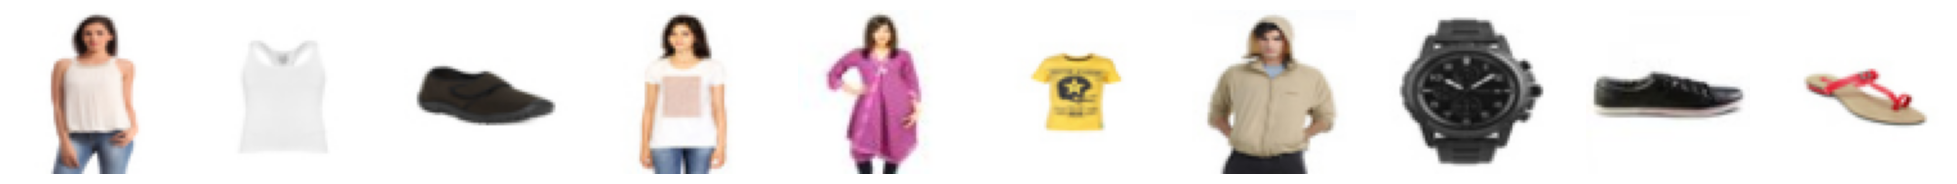

In [85]:
# 对比显示预测结果
fig, axes = plt.subplots(1, 10, figsize=(25, 4), sharey=True, sharex=True)
for i in range(10):
    axes[i].imshow(images[i])
    axes[i].axis('off')
    # 真实标签
    print(f"{i+1}-label: {targets[i]}")
    # 预测标签
    print(f"{i+1}-pred: {classification_names[pred_labels[i]]}")
    print()
plt.show()

In [86]:
# 计算测试集准确率
test_acc_num = 0
with torch.no_grad():
    for input, target in test_loader:
        input = input.to(device)
        target = target.to(device)
        # 前向传播
        output = model(input)
        # 得到预测分类
        pred_labels = output.argmax(dim=1)
        # 累加预测正确的数量
        test_acc_num += (pred_labels == target).sum().item()

print(f"测试集准确率: {test_acc_num / len(test_dataset):.4f}")



测试集准确率: 0.9876
